# NTU 时间序列折线图

读取 `data/merged.xlsx`，按日期和时间整理出厂水浊度 `NTU`，绘制完整观测期的折线图。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

possible_paths = [Path("data/merged.xlsx"), Path("../data/merged.xlsx")]
DATA_PATH = next((path for path in possible_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("找不到 data/merged.xlsx，请从项目根目录或 temp 目录运行 notebook。")

print(f"数据文件：{DATA_PATH.resolve()}")

数据文件：/Users/jinyu/workspace/2026亚太杯/data/merged.xlsx


In [2]:
df = pd.read_excel(DATA_PATH, sheet_name="Merged")

date_text = pd.to_datetime(df["DATE"], errors="coerce").dt.strftime("%Y-%m-%d")
time_text = df["TIME"].astype(str).str.strip()
df["DATETIME"] = pd.to_datetime(date_text + " " + time_text, errors="coerce")
df["NTU"] = pd.to_numeric(df["NTU"], errors="coerce")

ntu = df[["DATETIME", "NTU"]].dropna(subset=["DATETIME"]).sort_values("DATETIME")

print(f"时间范围：{ntu['DATETIME'].min()} 至 {ntu['DATETIME'].max()}")
print(f"总记录数：{len(ntu):,}")
print(f"NTU 有效观测：{ntu['NTU'].notna().sum():,}")
print(f"NTU 缺失：{ntu['NTU'].isna().sum():,}")
ntu.head()

时间范围：2025-01-01 07:00:00 至 2026-04-01 05:00:00
总记录数：5,460
NTU 有效观测：5,124
NTU 缺失：336


,DATETIME,NTU
0,2025-01-01 07:00:00,0.12
1,2025-01-01 09:00:00,0.12
2,2025-01-01 11:00:00,0.12
3,2025-01-01 13:00:00,0.11
4,2025-01-01 15:00:00,0.11


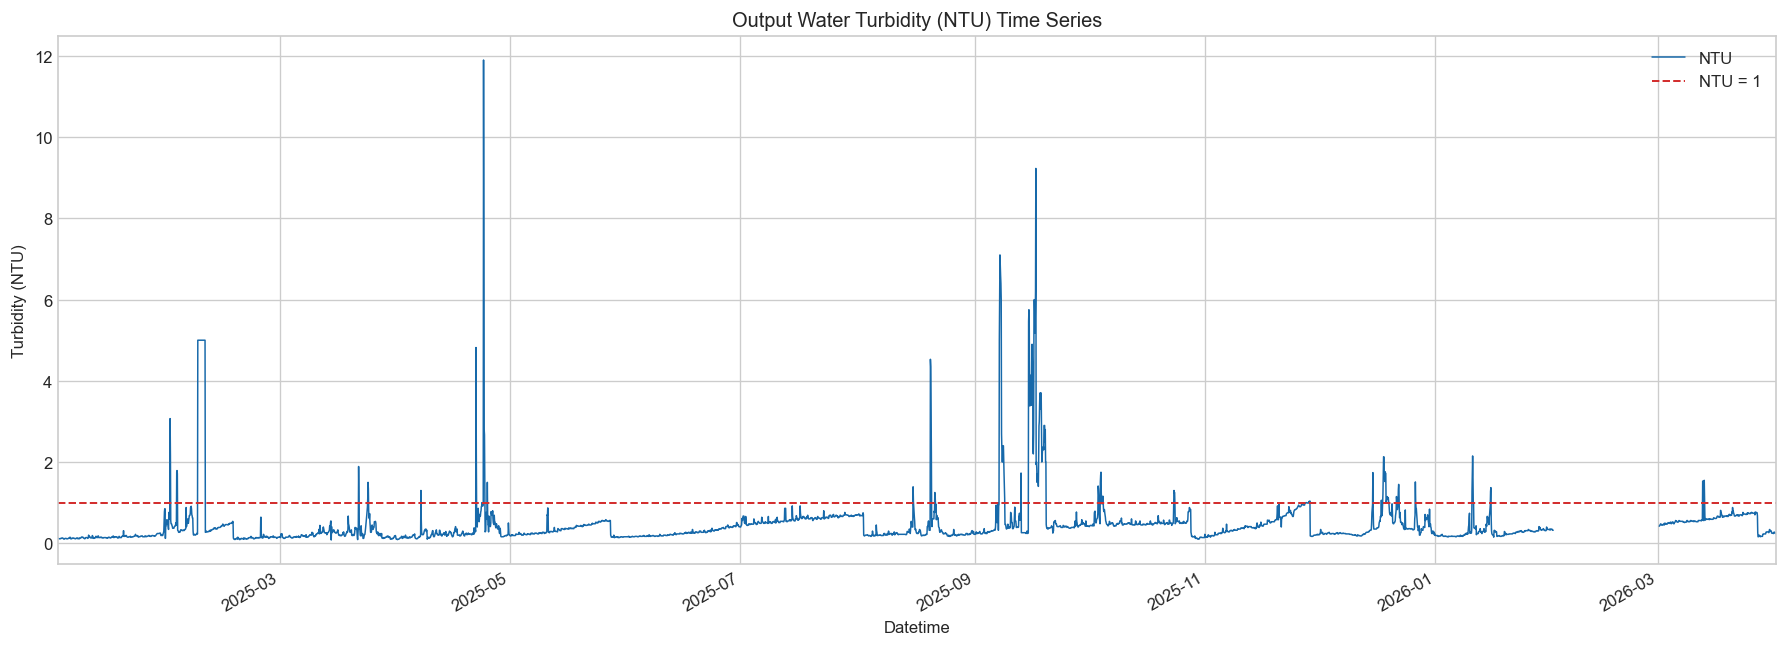

In [3]:
fig, ax = plt.subplots(figsize=(15, 5.5))

ax.plot(
    ntu["DATETIME"],
    ntu["NTU"],
    color="#1769aa",
    linewidth=0.9,
    label="NTU",
)
ax.axhline(1.0, color="#d32f2f", linestyle="--", linewidth=1.2, label="NTU = 1")

ax.set_title("Output Water Turbidity (NTU) Time Series")
ax.set_xlabel("Datetime")
ax.set_ylabel("Turbidity (NTU)")
ax.legend()
ax.margins(x=0)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()